In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Načtení dat ze souboru CSV v podadresáři 'data'
data = pd.read_csv('data/world_bank_indicators.csv')
data_train=pd.read_csv('data/train_data2.csv')
data_test=pd.read_csv('data/test_data2.csv')
# Shrnutí dat a seznam názvů sloupců
print("Souhrn dat:")
print(data.describe())
print("\nSeznam názvů sloupců:")
print(list(data.columns))



Souhrn dat:
               year  Access to electricity (% of population)  \
count  16960.000000                              7611.000000   
mean    1991.500000                                81.045979   
std       18.473498                                28.546144   
min     1960.000000                                 0.533899   
25%     1975.750000                                69.653940   
50%     1991.500000                                98.400000   
75%     2007.250000                               100.000000   
max     2023.000000                               100.000000   

       Adjusted net savings, including particulate emission damage (% of GNI)  \
count                                        5429.000000                        
mean                                            7.793301                        
std                                            11.557922                        
min                                          -166.127193                        
25%   

In [18]:
from definitions import FuzzyRelations
from definitions import models
from definitions import models as md
from definitions import quantifiers
import numpy as np
import openpyxl

from importlib import reload  # Python 3.4+
FuzzyRelations = reload(FuzzyRelations)
models = reload(models)
quantifiers = reload(quantifiers)
X = data['GDP per capita (current US$)']
Y = data['Fertility rate, total (births per woman)']
X_test = data_test['GDP per capita (current US$)']
Y_test = data_test['Fertility rate, total (births per woman)']

# Remove NaN rows
mask = pd.notnull(X) & pd.notnull(Y)
mask_test = pd.notnull(X_test) & pd.notnull(Y_test)
X = X[mask]
Y = Y[mask]
X_test = X_test[mask_test]
Y_test = Y_test[mask_test]

# Union of values (unique elements from both arrays)
Y_union = np.union1d(Y, Y_test)
X_union = np.union1d(X, X_test)

# Compute min and max
y_min = np.min(Y_union)
y_max = np.max(Y_union)
x_min = np.min(X_union)
x_max = np.max(X_union)

print("Union size:", Y_union.shape[0])
print("y_min:", y_min)
print("y_max:", y_max)

Union size: 7640
y_min: 0.701
y_max: 8.606


## Load and Plot the Model

In [3]:
import pickle

with open("models/model10Rules_training_WorldBank_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
print(loaded_model["quantifier"])
print(loaded_model["nodesx"])
print(loaded_model.keys()) 
# Předpokládáme, že nodesyL a nodesyR jsou stejně dlouhé seznamy čísel
quant=loaded_model["quantifier"]
nodesyL = loaded_model["nodesyL"]
nodesyR = loaded_model["nodesyR"]

# Výpočet průměru pro každý odpovídající prvek
averaged_y = [(l + r) / 2 for l, r in zip(nodesyL, nodesyR)]
# Výpočet průměru pro každý odpovídající prvek
diff_y = [r-l for l, r in zip(nodesyL, averaged_y)]

print(averaged_y)
print(diff_y)

[0.75, 0.78, 0.92, 0.93, 0.95, 0.96, 0.97, 0.98, 0.99, 0.99]
[11.8013216739, 19688.994130965806, 39366.186940257714, 59043.37974954962, 78720.57255884154, 98397.76536813345, 118074.95817742535, 137752.15098671726, 157429.34379600917, 177106.53660530108, 196784.729414593]
dict_keys(['ModelQuantifiedRules', 'nodesx', 'nodesyL', 'nodesyR', 'x', 'y', 'quantifier', 'maxx', 'minx', 'maxfx', 'minfx', 'decl', 'dx'])
[3.983288782317455, 3.4758548678606402, 1.8890308307388175, 1.7764074694507315, 1.682791854281427, 1.5790385147612016, 1.5335946559796052, 1.4817439455180528, 1.5052886808954853, 1.5083273385814235]
[1.7086613364586398, 1.6568464601022248, 0.4465572465696057, 0.3132658008374807, 0.234186356649426, 0.1859502944520668, 0.16719538088681696, 0.10846965777528306, 0.07746477661234286, 0.0676600534316043]


## Test the Model's Precision

In [14]:
models = reload(models)


500 rules with decl 18

693
693
Predikce: [4.270815751445086, 4.09375289017341, 1.786223988439306, 1.8376293352601154, 4.168005057803468, 4.390761560693641, 2.026115606936416, 4.390761560693641, 4.3507796242774575, 4.413608381502891, 3.071357658959538, 4.019500722543352, 4.390761560693641, 4.305085982658959, 4.168005057803468, 4.310797687861272, 4.345067919075144, 4.3507796242774575, 1.9118815028901732, 3.037087427745665, 1.7805122832369942, 4.316509393063583, 4.413608381502891, 2.563015895953757, 4.019500722543352, 4.299374277456647, 2.682961705202312, 2.1689082369942194, 2.5915744219653174, 2.4373583815028903, 2.9399884393063584, 4.390761560693641, 2.762925578034682, 2.8029075144508666, 4.390761560693641, 3.1056278901734102, 3.071357658959538, 3.225573699421966, 4.310797687861272, 2.9000065028901734, 2.6201329479768787, 4.259392341040462, 4.407896676300578, 2.8257543352601155, 4.345067919075144, 2.962835260115607, 2.8257543352601155, 3.8195910404624276, 4.025212427745664, 2.7172319364161854, 2.3402593930635

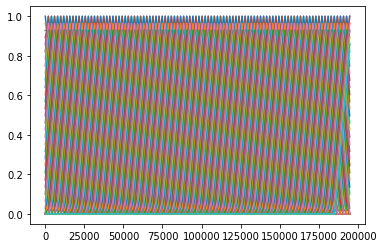

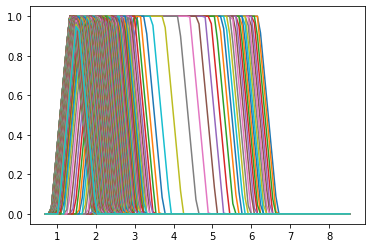

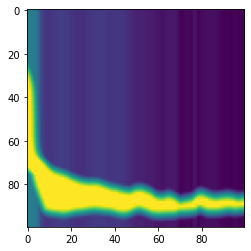

In [32]:
import pickle
with open("500rules_decl18_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
y_pred,metrics = md.QRules_defuzz_eval(
    model=loaded_model,
    xtest=X_test,
    ytest=Y_test,
    ymin=y_min,
    ymax=y_max,
    defuzz="MOM"  # nebo "MOM", "COG", "MaxOM", "MinOM"
)

print("Predikce:", y_pred)
print("MAE:", metrics["MAE"])
print("RMSE:", metrics["RMSE"])

values=md.QRules_values(loaded_model)
plt.imshow(np.flipud(values))  

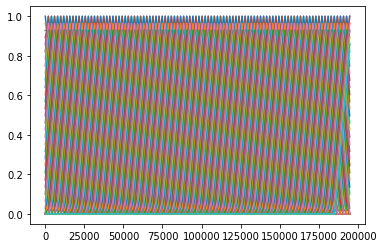

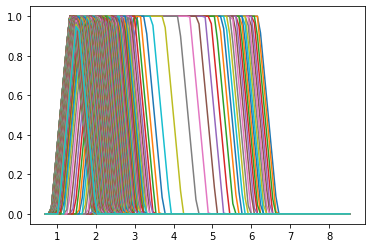

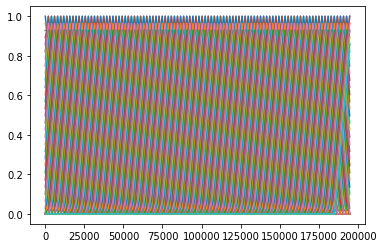

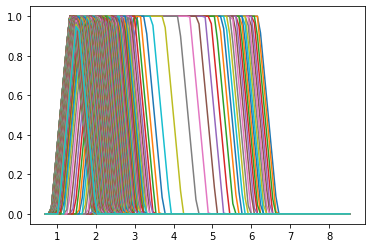

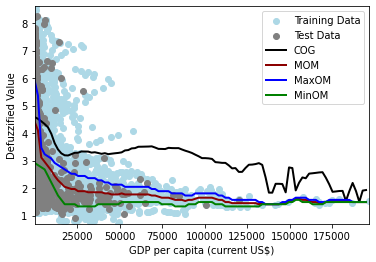

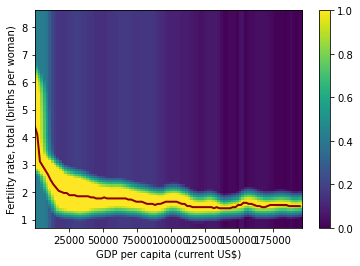

In [36]:
xy=[x_min,x_max,y_min,y_max]# Výpis a graf
values=md.QRules_values(loaded_model)
defuzz=md.QRules_defuzz_plot(loaded_model,values,data_train,data_test)
disx=100
x=[x_min+k*((x_max-x_min)/disx) for k in range(0,disx)]
plt.imshow(values,extent =[xy[0], xy[1], xy[2], xy[3]], 
           cmap='viridis', interpolation='nearest', origin='lower', aspect='auto')
# Překreslení křivek
plt.plot(x, defuzz["moms"], label='MOM', color='darkred', linewidth=2)
plt.colorbar()
plt.xlabel('GDP per capita (current US$)')
plt.ylabel('Fertility rate, total (births per woman)')
plt.show()

40 rules with decl 10

693
693
Predikce: [4.036635838150288, 4.019500722543352, 1.7748005780346816, 1.860476156069364, 4.0252124277456645, 4.1965635838150295, 2.2488721098265896, 4.1965635838150295, 4.053770953757224, 4.1965635838150295, 3.2198619942196536, 4.013789017341041, 4.1965635838150295, 4.0423475433526015, 4.0252124277456645, 4.0423475433526015, 4.048059248554914, 4.048059248554914, 1.9861336705202313, 3.2141502890173417, 1.7748005780346816, 4.048059248554914, 4.1965635838150295, 2.6601148843930633, 4.013789017341041, 4.036635838150288, 2.7172319364161845, 2.4202232658959537, 2.6772500000000004, 2.5801510115606936, 3.1627449421965315, 4.1965635838150295, 2.7629255780346824, 2.780060693641619, 4.190851878612716, 3.225573699421966, 3.2198619942196536, 3.2369971098265893, 4.048059248554914, 3.128474710982659, 2.6829617052023127, 4.036635838150288, 4.1965635838150295, 2.785772398843931, 4.048059248554914, 3.1741683526011557, 2.785772398843931, 4.008077312138729, 4.019500722543352, 2.7343670520231207, 2.

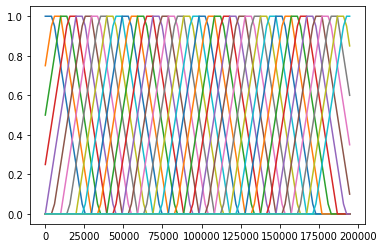

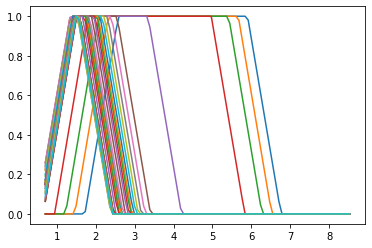

In [30]:
import pickle
with open("40rules_decl10_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
y_pred,metrics = md.QRules_defuzz_eval(
    model=loaded_model,
    xtest=X_test,
    ytest=Y_test,
    ymin=y_min,
    ymax=y_max,
    defuzz="MOM"  # nebo "MOM", "COG", "MaxOM", "MinOM"
)

print("Predikce:", y_pred)
print("MAE:", metrics["MAE"])
print("RMSE:", metrics["RMSE"])
print("R2:", metrics["R2"])

values=md.QRules_values(loaded_model)

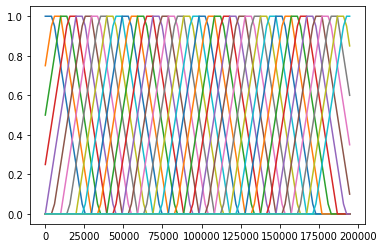

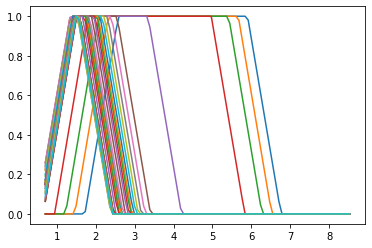

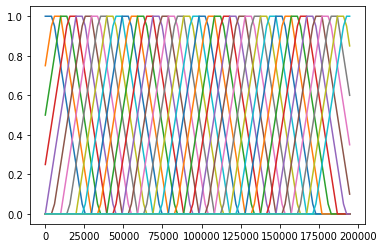

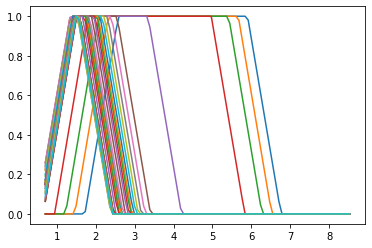

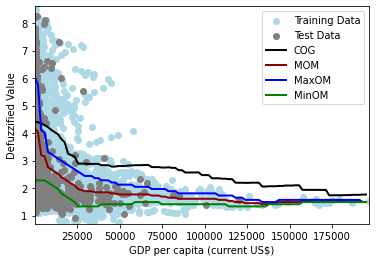

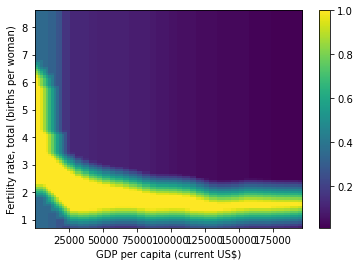

In [31]:
xy=[x_min,x_max,y_min,y_max]# Výpis a graf
values=md.QRules_values(loaded_model)
defuzz=md.QRules_defuzz_plot(loaded_model,values,data_train,data_test)
plt.imshow(values,extent =[xy[0], xy[1], xy[2], xy[3]], 
           cmap='viridis', interpolation='nearest', origin='lower', aspect='auto')
plt.colorbar()
plt.xlabel('GDP per capita (current US$)')
plt.ylabel('Fertility rate, total (births per woman)')
plt.show()

5 rules with decl 5

In [26]:
models=reload(models)

693
693
Predikce: [3.8995549132947964, 3.8995549132947964, 1.9975570809248553, 2.5001871387283234, 3.8995549132947964, 3.8995549132947964, 2.894294797687861, 3.8995549132947964, 3.8995549132947964, 3.8995549132947964, 3.2255736994219655, 3.8995549132947964, 3.8995549132947964, 3.8995549132947964, 3.8995549132947964, 3.8995549132947964, 3.8995549132947964, 3.8995549132947964, 2.734367052023121, 3.2141502890173412, 1.9918453757225432, 3.8995549132947964, 3.8995549132947964, 3.088492774566474, 3.8995549132947964, 3.8995549132947964, 3.117051300578035, 2.9685469653179193, 3.0999161849710983, 3.048510838150289, 3.1855917630057804, 3.8995549132947964, 3.1398981213872834, 3.1513215317919077, 3.8995549132947964, 3.2255736994219655, 3.2255736994219655, 3.8995549132947964, 3.8995549132947964, 3.1684566473988443, 3.0999161849710983, 3.8995549132947964, 3.8995549132947964, 3.1513215317919077, 3.8995549132947964, 3.1913034682080927, 3.1513215317919077, 3.8995549132947964, 3.8995549132947964, 3.1284

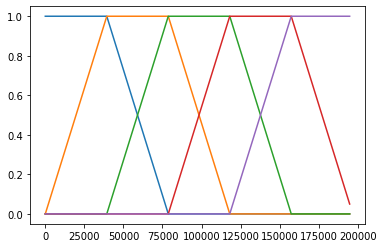

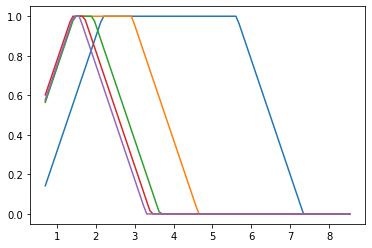

In [37]:
import pickle
with open("5rules_decl5_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
y_pred,metrics = md.QRules_defuzz_eval(
    model=loaded_model,
    xtest=X_test,
    ytest=Y_test,
    ymin=y_min,
    ymax=y_max,
    defuzz="MOM"  # nebo "MOM", "COG", "MaxOM", "MinOM"
)

print("Predikce:", y_pred)
print("MAE:", metrics["MAE"])
print("RMSE:", metrics["RMSE"])
print("R2:", metrics["R2"])
xy=[x_min,x_max,y_min,y_max]# Výpis a graf
values=md.QRules_values(loaded_model)


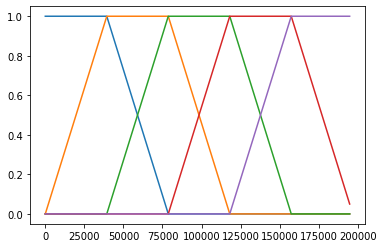

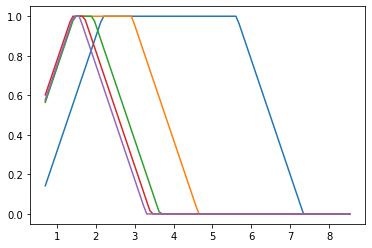

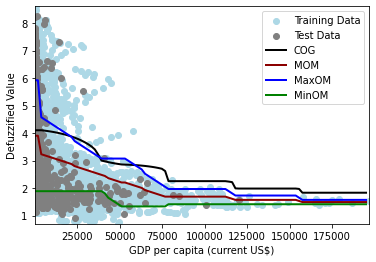

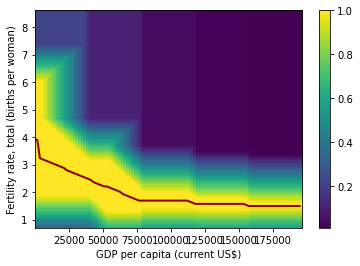

In [38]:
defuzz=md.QRules_defuzz_plot(loaded_model,values,data_train,data_test)
disx=100
x=[x_min+k*((x_max-x_min)/disx) for k in range(0,disx)]
plt.imshow(values,extent =[xy[0], xy[1], xy[2], xy[3]], 
           cmap='viridis', interpolation='nearest', origin='lower', aspect='auto')
# Překreslení křivek
plt.plot(x, defuzz["moms"], label='MOM', color='darkred', linewidth=2)
plt.colorbar()
plt.xlabel('GDP per capita (current US$)')
plt.ylabel('Fertility rate, total (births per woman)')
plt.show()

In [ ]:
nodesyL = np.array(loaded_model["nodesyL"], dtype=float)
nodesyR = np.array(loaded_model["nodesyR"], dtype=float)

# Elementwise averages (midpoints)
pair_avg = (nodesyL + nodesyR) / 2.0

# Distance of nodeL from the average  ⟵ (you had nodesyR by mistake)
dist_nodeL_from_avg = np.abs(nodesyL - pair_avg)

TypeError: unsupported operand type(s) for /: 'list' and 'float'